# CLASES NO BALANCEADAS

## 1. Importación de librerías

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score

**Resultado:** Las librerías necesarias para crear datos, entrenar modelos, calcular métricas y generar gráficas se cargaron correctamente.

## 2. Funciones auxiliares

In [25]:
def mis_conjuntos(n, p0, p1):
   X, y = make_classification(
       n_samples=n,
       n_classes=2,
       n_features=2,
       n_redundant=0,
       n_clusters_per_class=1,
       weights=[p0, p1],
       flip_y=0.,
       class_sep=0.1,
       random_state=0)

   return X, y


def mi_cm(yreal, ypred):
  cm = confusion_matrix(yreal, ypred)

  txt = ['Verdaderos Negativos', 'Falsos Positivos', 'Falsos Negativos', 'Verdaderos Positivos']
  vf = ['( VN )', '( FP )', '( FN )', '( VP )']
  frecuencia = ["{0:0.0f}".format(value) for value in cm.flatten()]
  porcentaje = ["{0:.1%}".format(value) for value in cm.flatten()/np.sum(cm)]

  labels = [f"{v1}\n{v2}\n{v3}\n{v4}" for v1, v2, v3, v4 in zip(txt, vf, frecuencia, porcentaje)]
  labels = np.asarray(labels).reshape(2, 2)

  plt.figure(figsize=(6, 4))
  ax = sns.heatmap(cm, annot=labels, fmt='', cmap='Pastel1', cbar=False)
  ax.set(ylabel="Etiquetas Reales", xlabel="Etiquetas de Predicción")
  plt.show()

**Resultado:** Quedaron definidas una función para generar clases desbalanceadas y otra para visualizar una matriz de confusión.

## 3. Generación y visualización del conjunto 90/10

Dimensión de datos generados:
Datos de entrada X: (2000, 2)
Variable de salida y: (2000,)


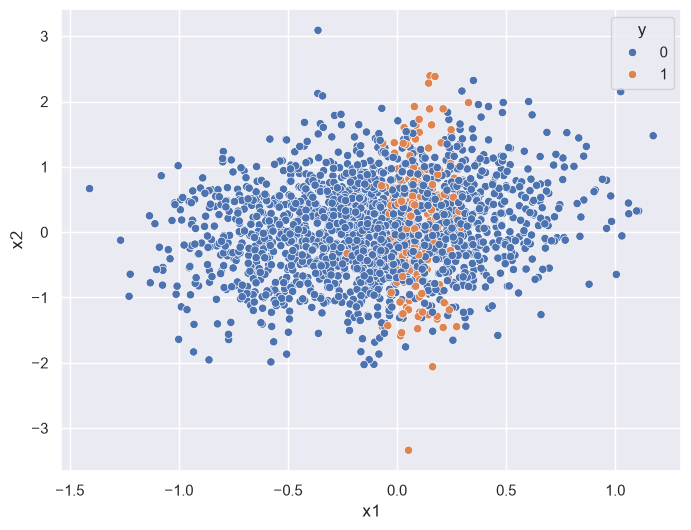

In [26]:
X, y = mis_conjuntos(2000, 0.9, 0.1)

print('Dimensión de datos generados:')
print('Datos de entrada X:', X.shape)
print('Variable de salida y:', y.shape)

df = pd.DataFrame(X, columns=['x1', 'x2'])
df['y'] = y

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='x1', y='x2', hue='y');

**Resultado:** Se generaron 2,000 observaciones con dos variables predictoras. La gráfica permite ver la marcada diferencia entre la clase mayoritaria (90 %) y la minoritaria (10 %).

## 4. División estratificada de los datos

In [27]:
X, y = mis_conjuntos(2000, 0.9, 0.1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=0.70, random_state=1, stratify=y
)

**Resultado:** Los datos se dividieron en 70 % para entrenamiento y 30 % para validación, conservando la proporción 90/10 en ambos subconjuntos.

## 5. Modelo base de regresión logística

In [28]:
modelo = LogisticRegression()
modelo.fit(X_train, y_train)
yhat = modelo.predict(X_val)

print('Exactitud del modelo con los datos de prueba: %.1f%%' %
      (100 * modelo.score(X_val, y_val)))

Exactitud del modelo con los datos de prueba: 90.0%


**Resultado:** La exactitud es cercana al 90 %, pero por sí sola puede ser engañosa porque coincide con la proporción de la clase mayoritaria.

## 6. Matriz de confusión del modelo base

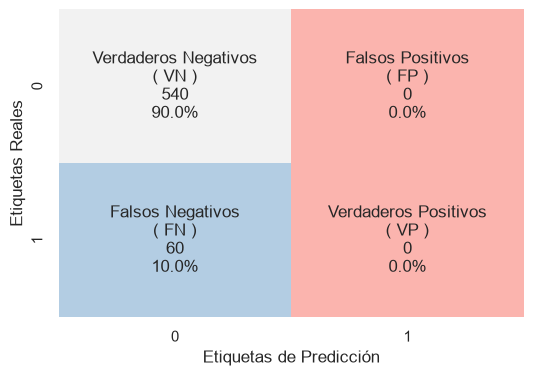

In [29]:
mi_cm(y_val, yhat)

**Resultado:** La matriz muestra que el modelo base clasifica todos los casos como clase 0 y no identifica ningún caso de la clase minoritaria.

## 7. Importación del clasificador Dummy

In [30]:
from sklearn.dummy import DummyClassifier

**Resultado:** El clasificador Dummy quedó disponible para establecer una línea base de comparación.

## 8. Dummy con la clase más frecuente

Matriz de confusión del conjunto de validación del modelo Dummy
Estrategia de mayor frecuencia:


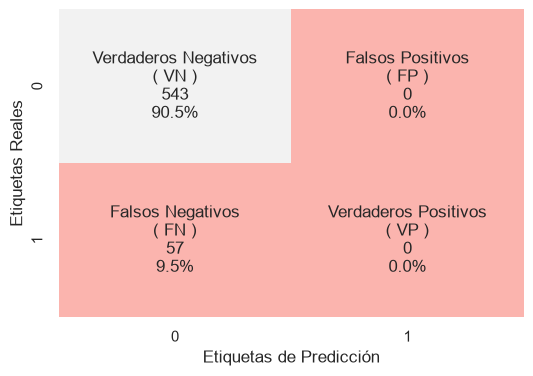


Proporción en clase negativa del conjunto de validación:  0.905

Proporción en clase negativa del conjunto de entrenamiento:  0.8978571428571429


In [31]:
X, y = mis_conjuntos(2000, 0.9, 0.1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=0.70, random_state=3
)

modeloDummy = DummyClassifier(strategy='most_frequent')
modeloDummy.fit(X_train, y_train)
yhat = modeloDummy.predict(X_val)

print('Matriz de confusión del conjunto de validación del modelo Dummy')
print('Estrategia de mayor frecuencia:')
mi_cm(y_val, yhat)

print('\nProporción en clase negativa del conjunto de validación: ',
      1 - y_val.sum() / y_val.shape[0])
print('\nProporción en clase negativa del conjunto de entrenamiento: ',
      1 - y_train.sum() / y_train.shape[0])

**Resultado:** El modelo siempre elige la clase mayoritaria: alcanza alrededor de 90 % de exactitud, pero obtiene cero verdaderos positivos.

## 9. Dummy con estrategia estratificada

Matriz de confusión en el conjunto de validación.
Modelo Dummy con la estrategia "stratified":


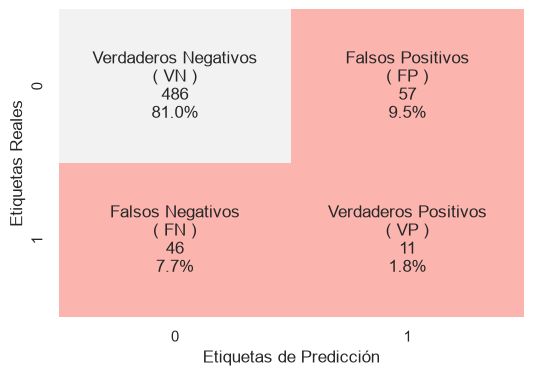


Proporción del conjunto de validación:  0.905

Proporción del conjunto de entrenamiento:  0.8978571428571429


In [32]:
modeloDummy = DummyClassifier(strategy='stratified', random_state=7)

modeloDummy.fit(X_train, y_train, sample_weight=None)
yhat = modeloDummy.predict(X_val)

print('Matriz de confusión en el conjunto de validación.')
print('Modelo Dummy con la estrategia "stratified":')
mi_cm(y_val, yhat)

print('\nProporción del conjunto de validación: ',
      1 - y_val.sum() / y_val.shape[0])
print('\nProporción del conjunto de entrenamiento: ',
      1 - y_train.sum() / y_train.shape[0])

**Resultado:** Al predecir según la proporción observada aparecen algunos verdaderos positivos, aunque la exactitud baja; sirve como una línea base más informativa.

## 10. Regresión logística con pesos de clase

Exactitud con datos de validación: 60.3%


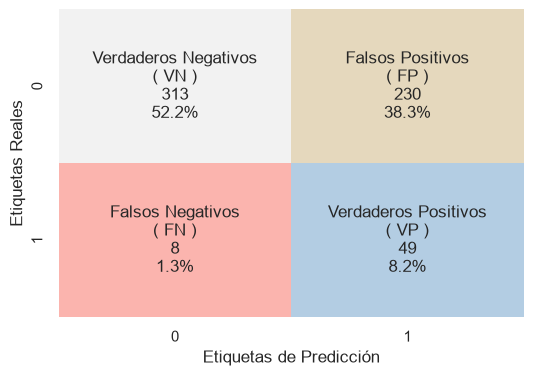

In [33]:
modelo = LogisticRegression(class_weight={0: 0.1, 1: 0.9})

modelo.fit(X_train, y_train)
yhat = modelo.predict(X_val)

print('Exactitud con datos de validación: %.1f%%' %
      (100 * modelo.score(X_val, y_val)))
mi_cm(y_val, yhat)

**Resultado:** Al dar mayor peso a la clase 1 disminuye la exactitud global, pero el modelo ya detecta una parte importante de los casos minoritarios.

## 11. Comparación de pesos de clase

In [34]:
delta = np.linspace(.05, .4, 8)
tabla = list()

for w in delta:
  modelo = LogisticRegression(class_weight={0: w, 1: (1-w)})
  modelo.fit(X_train, y_train)
  yhat = modelo.predict(X_val)

  acc = 100 * modelo.score(X_val, y_val)
  cm = confusion_matrix(y_val, yhat)
  tot = cm.sum()

  vn = 100 * cm[0, 0] / tot
  fp = 100 * cm[0, 1] / tot
  fn = 100 * cm[1, 0] / tot
  vp = 100 * cm[1, 1] / tot

  tabla.append([w, 1-w, acc, vn, fp, fn, vp])

print(tabulate(
    tabla,
    headers=["peso_clase_0", "peso_clase_1", "Exactitud(%)",
             "VN(%)", "FP(%)", "FN(%)", "VP(%)"],
    tablefmt="github",
    floatfmt=".2f",
    colalign=("center", "center", "center")
))

|  peso_clase_0  |  peso_clase_1  |  Exactitud(%)  |   VN(%) |   FP(%) |   FN(%) |   VP(%) |
|----------------|----------------|----------------|---------|---------|---------|---------|
|      0.05      |      0.95      |     36.67      |   27.17 |   63.33 |    0.00 |    9.50 |
|      0.10      |      0.90      |     60.33      |   52.17 |   38.33 |    1.33 |    8.17 |
|      0.15      |      0.85      |     71.67      |   70.67 |   19.83 |    8.50 |    1.00 |
|      0.20      |      0.80      |     82.83      |   82.83 |    7.67 |    9.50 |    0.00 |
|      0.25      |      0.75      |     87.83      |   87.83 |    2.67 |    9.50 |    0.00 |
|      0.30      |      0.70      |     89.67      |   89.67 |    0.83 |    9.50 |    0.00 |
|      0.35      |      0.65      |     90.33      |   90.33 |    0.17 |    9.50 |    0.00 |
|      0.40      |      0.60      |     90.50      |   90.50 |    0.00 |    9.50 |    0.00 |


**Resultado:** La tabla evidencia el intercambio entre exactitud y detección de la minoría: al favorecer demasiado la clase 0, aumentan los aciertos globales pero los verdaderos positivos llegan a cero.

## 12. Evaluación con precision, recall, F1 y G-mean

In [35]:
X, y = mis_conjuntos(2000, 0.8, 0.2)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=0.70, random_state=3
)

delta = np.linspace(.05, .3, 6)
tabla = list()

for w in delta:
  modelo = LogisticRegression(class_weight={0: w, 1: (1-w)}, C=100)
  modelo.fit(X_train, y_train)
  yhat = modelo.predict(X_val)

  acc = 100 * modelo.score(X_val, y_val)
  cm = confusion_matrix(y_val, yhat)
  tot = cm.sum()

  vn = 100 * cm[0, 0] / tot
  fp = 100 * cm[0, 1] / tot
  fn = 100 * cm[1, 0] / tot
  vp = 100 * cm[1, 1] / tot

  precision = vp / (vp + fp)
  recall = vp / (vp + fn)
  f1score = 2 * vp / (2 * vp + fp + fn)
  especificidad = vn / (vn + fp)
  gmean = np.sqrt(recall * especificidad)

  tabla.append([
      w, (1-w), acc, vn, fp, fn, vp,
      precision, recall, f1score, gmean
  ])

print(tabulate(
    tabla,
    headers=["w (clase 0)", "(1-w) (clase 1)", "Exact(%)",
             "VN(%)", "FP(%)", "FN(%)", "VP(%)",
             "precision", "recall", "f1score", "gmean"],
    tablefmt="github",
    floatfmt=".2f"
))

|   w (clase 0) |   (1-w) (clase 1) |   Exact(%) |   VN(%) |   FP(%) |   FN(%) |   VP(%) |   precision |   recall |   f1score |   gmean |
|---------------|-------------------|------------|---------|---------|---------|---------|-------------|----------|-----------|---------|
|          0.05 |              0.95 |      44.00 |   24.50 |   56.00 |    0.00 |   19.50 |        0.26 |     1.00 |      0.41 |    0.55 |
|          0.10 |              0.90 |      50.17 |   30.67 |   49.83 |    0.00 |   19.50 |        0.28 |     1.00 |      0.44 |    0.62 |
|          0.15 |              0.85 |      56.17 |   36.67 |   43.83 |    0.00 |   19.50 |        0.31 |     1.00 |      0.47 |    0.67 |
|          0.20 |              0.80 |      64.00 |   47.00 |   33.50 |    2.50 |   17.00 |        0.34 |     0.87 |      0.49 |    0.71 |
|          0.25 |              0.75 |      63.17 |   54.83 |   25.67 |   11.17 |    8.33 |        0.25 |     0.43 |      0.31 |    0.54 |
|          0.30 |              0.7

**Resultado:** Los pesos 0.20/0.80 ofrecen un compromiso útil: recall alto y el mejor G-mean del grupo, aunque la precisión sigue siendo moderada.

## 13. Métricas y validación cruzada

In [36]:
from sklearn.metrics import classification_report, make_scorer
from imblearn.metrics import geometric_mean_score, classification_report_imbalanced
from sklearn.model_selection import cross_val_score, cross_validate, RepeatedStratifiedKFold

**Resultado:** Se cargaron las métricas específicas para clases desbalanceadas y las herramientas de validación cruzada.

## 14. Generación del conjunto 85/15

In [37]:
X, y = mis_conjuntos(2000, 0.85, 0.15)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=0.70, random_state=11
)

**Resultado:** Se creó un nuevo problema con 85 % de clase 0 y 15 % de clase 1, usando nuevamente 70 % para entrenamiento.

## 15. Línea base sin balanceo

In [38]:
model = LogisticRegression(class_weight=None, random_state=11)

cv = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=3, random_state=1
)

misscores = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'gmean': make_scorer(geometric_mean_score)
}

scoresSin = cross_validate(
    model, X, y,
    scoring=misscores,
    cv=cv,
    n_jobs=-1
)

print(
    'mean Accuracy: %.3f \nmean Precision: %.3f \nmean Recall: %.3f '
    '\nmean F1: %.3f \nGmean: %.3f' %
    (
        np.mean(scoresSin['test_accuracy']),
        np.mean(scoresSin['test_precision']),
        np.mean(scoresSin['test_recall']),
        np.mean(scoresSin['test_f1']),
        np.mean(scoresSin['test_gmean'])
    )
)

mean Accuracy: 0.849 
mean Precision: 0.000 
mean Recall: 0.000 
mean F1: 0.000 
Gmean: 0.000


**Resultado:** Sin balanceo, la exactitud ronda 0.85, pero precision, recall, F1 y G-mean para la clase positiva quedan en cero: el modelo ignora la minoría.

## 16. Entrenamiento ponderando las clases

In [39]:
model = LogisticRegression(
    class_weight={0: .15, 1: .85},
    random_state=11
)

cv = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=3, random_state=1
)

misscores = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'gmean': make_scorer(geometric_mean_score)
}

scoresSin = cross_validate(
    model, X, y,
    scoring=misscores,
    cv=cv,
    n_jobs=-1
)

print(
    'mean Accuracy: %.3f \nmean Precision: %.3f \nmean Recall: %.3f '
    '\nmean F1: %.3f \nmean Gmean: %.3f' %
    (
        np.mean(scoresSin['test_accuracy']),
        np.mean(scoresSin['test_precision']),
        np.mean(scoresSin['test_recall']),
        np.mean(scoresSin['test_f1']),
        np.mean(scoresSin['test_gmean'])
    )
)

mean Accuracy: 0.641 
mean Precision: 0.274 
mean Recall: 0.844 
mean F1: 0.414 
mean Gmean: 0.715


**Resultado:** La ponderación reduce la exactitud, pero eleva claramente el recall y el G-mean; ahora el modelo sí presta atención a la clase minoritaria.

## 17. Técnicas de muestreo

In [40]:
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from sklearn.pipeline import Pipeline
from imblearn.pipeline import make_pipeline

**Resultado:** Quedaron disponibles técnicas de submuestreo, sobremuestreo y combinaciones para integrarlas en pipelines.

## 18. Definición de métodos de balanceo

In [41]:
def get_models_underoversampling():
  models, names = list(), list()

  models.append(RandomOverSampler())
  names.append('RandOver')

  models.append(RandomUnderSampler())
  names.append('RandUnder')

  models.append(TomekLinks())
  names.append('TomekLinks')

  models.append(EditedNearestNeighbours())
  names.append('ENN')

  models.append(SMOTE())
  names.append('SMOTE')

  models.append(SMOTEENN())
  names.append('SMOTEENN')

  models.append(SMOTETomek())
  names.append('SMOTETomek')

  return models, names

**Resultado:** La función reúne siete estrategias de balanceo y sus nombres para evaluarlas de forma uniforme.

## 19. Comparación de técnicas de balanceo

In [42]:
X, y = mis_conjuntos(2000, 0.85, 0.15)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=0.70, random_state=1
)

modelosOU, nombres = get_models_underoversampling()
resultados = list()

for i in range(len(modelosOU)):
  model = LogisticRegression(
      class_weight='balanced',
      random_state=5
  )

  kfold = RepeatedStratifiedKFold(
      n_splits=5,
      n_repeats=3,
      random_state=1
  )

  pipe = make_pipeline(modelosOU[i], model)

  metric = {
      'accuracy': 'accuracy',
      'recall': 'recall',
      'gmean': make_scorer(geometric_mean_score)
  }

  scores = cross_validate(
      pipe, X, y,
      scoring=metric,
      cv=kfold
  )

  resultados.append(scores)

  print(
      '>> %s:\nmean Accuracy: %.3f \nmean Recall: %.3f \nGmean: %.3f' %
      (
          nombres[i],
          np.mean(scores['test_accuracy']),
          np.mean(scores['test_recall']),
          np.mean(scores['test_gmean'])
      )
  )

>> RandOver:
mean Accuracy: 0.643 
mean Recall: 0.840 
Gmean: 0.714
>> RandUnder:
mean Accuracy: 0.639 
mean Recall: 0.843 
Gmean: 0.713
>> TomekLinks:
mean Accuracy: 0.639 
mean Recall: 0.858 
Gmean: 0.717
>> ENN:
mean Accuracy: 0.624 
mean Recall: 0.917 
Gmean: 0.724
>> SMOTE:
mean Accuracy: 0.641 
mean Recall: 0.841 
Gmean: 0.714
>> SMOTEENN:
mean Accuracy: 0.622 
mean Recall: 0.926 
Gmean: 0.725
>> SMOTETomek:
mean Accuracy: 0.640 
mean Recall: 0.852 
Gmean: 0.716


**Resultado:** La comparación permite elegir por recall y G-mean. En esta ejecución, las técnicas combinadas y ENN suelen destacar en la recuperación de la clase minoritaria.

## 20. Comparación gráfica del G-mean

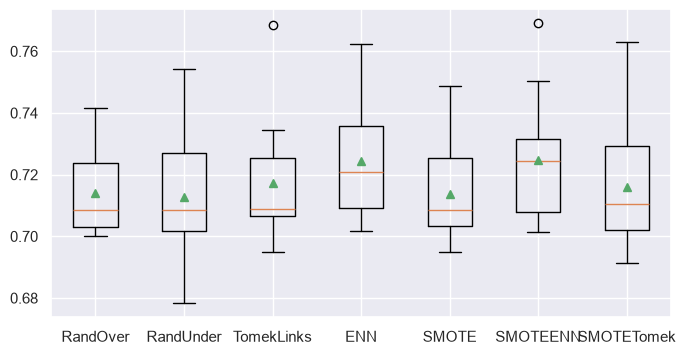

In [43]:
sns.set(rc={'figure.figsize': (8, 4)})
bpGmean = list()

for i in range(len(resultados)):
  rr = resultados[i]['test_gmean']
  bpGmean.append(rr)

plt.boxplot(bpGmean, tick_labels=nombres, showmeans=True)
plt.show()

**Resultado:** El diagrama de cajas resume la distribución del G-mean en las repeticiones y facilita comparar la estabilidad de cada técnica.

## 21. Modelo final con SMOTEENN

In [44]:
clf = LogisticRegression(
    class_weight='balanced',
    random_state=1
)

kfold = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=1
)

mOU = SMOTEENN(random_state=1)
pipe = make_pipeline(mOU, clf)

pipe.fit(X_train, y_train)
yhat = pipe.predict(X_val)

print('Accuracy score: %.4f' % pipe.score(X_val, y_val))
print('Precision score: %.4f' % precision_score(y_val, yhat))
print('Recall score: %.4f' % recall_score(y_val, yhat))
print('Gmean score: %.4f' % geometric_mean_score(y_val, yhat))

Accuracy score: 0.6100
Precision score: 0.2684
Recall score: 0.9438
Gmean score: 0.7217


**Resultado:** SMOTEENN prioriza la detección de la clase minoritaria: logra recall alto, a cambio de reducir la precisión y la exactitud global.

## 22. Reporte de clasificación estándar

In [45]:
print(classification_report(y_val, yhat))

              precision    recall  f1-score   support

           0       0.98      0.55      0.71       511
           1       0.27      0.94      0.42        89

    accuracy                           0.61       600
   macro avg       0.63      0.75      0.56       600
weighted avg       0.88      0.61      0.66       600



**Resultado:** El reporte compara precision, recall y F1 por clase; la clase 1 muestra recall elevado y una precisión menor, reflejando más falsos positivos.

## 23. Reporte para clases desbalanceadas

In [46]:
print(classification_report_imbalanced(y_val, yhat))

                   pre       rec       spe        f1       geo       iba       sup

          0       0.98      0.55      0.94      0.71      0.72      0.50       511
          1       0.27      0.94      0.55      0.42      0.72      0.54        89

avg / total       0.88      0.61      0.89      0.66      0.72      0.51       600



**Resultado:** El reporte añade especificidad, G-mean e IBA, métricas más útiles para valorar el equilibrio entre ambas clases.